In [4]:
# CELL 1 — INSTALL ONLY MISSING DEPENDENCIES
# Do not replace Kaggle's torch, torchvision, numpy, or Pillow builds.
!pip install -q --no-deps facenet-pytorch==2.6.0
!pip install -q --only-binary=:all: pillow-heif

In [5]:
# CELL 2 — IMPORTS, SEEDS, PATHS, AND CONFIGURATION
import copy
import gc
import hashlib
import json
import os
import random
import shutil
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from pillow_heif import register_heif_opener
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b3
from facenet_pytorch import MTCNN

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from IPython.display import FileLink, display

register_heif_opener()
ImageFile.LOAD_TRUNCATED_IMAGES = False

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
assert DEVICE == "cuda", "Enable a Kaggle GPU accelerator before feature extraction."

DATA_ROOT=Path("/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/DefakeX")
ANNOTATION_CSV=Path("/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_annotations_final.csv")
MODEL_ROOT=Path("/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint")
OUTPUT_DIR=Path("/kaggle/working/defakex_experiment_2")
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

TARGET_SIZE=224; RESIZE_SIZE=256; FFT_CLIP_MAX=14.0
IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]
SUPPORTED_EXTENSIONS={".jpg",".jpeg",".png",".webp",".bmp",".tif",".tiff",".heic",".heif"}
CHECKPOINT_EVERY=100

print("Device:",DEVICE)
print("DATA_ROOT:",DATA_ROOT)
print("ANNOTATION_CSV:",ANNOTATION_CSV)
print("MODEL_ROOT:",MODEL_ROOT)
print("OUTPUT_DIR:",OUTPUT_DIR)

Device: cuda
DATA_ROOT: /kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/DefakeX
ANNOTATION_CSV: /kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_annotations_final.csv
MODEL_ROOT: /kaggle/input/datasets/kashirhanif/frequency-model-checkpoint
OUTPUT_DIR: /kaggle/working/defakex_experiment_2


In [6]:
# CELL 3 — LOAD AND VERIFY TRAIN/VALIDATION MANIFESTS
assert DATA_ROOT.exists(),f"Missing image root: {DATA_ROOT}"
assert ANNOTATION_CSV.exists(),f"Missing corrected annotation CSV: {ANNOTATION_CSV}"

ann=pd.read_csv(ANNOTATION_CSV,dtype=str,keep_default_na=False)
ann.columns=[c.strip().lower() for c in ann.columns]
required={"image_id","filepath","final_split"}
assert required.issubset(ann.columns),f"Missing columns: {required-set(ann.columns)}"

label_col="label_norm" if "label_norm" in ann.columns else "label"
assert label_col in ann.columns
ann["label_norm"]=ann[label_col].str.strip().str.lower().replace({"ai":"fake","generated":"fake","1":"fake","0":"real"})
ann["final_split"]=ann["final_split"].str.strip().str.lower().replace({"val":"validation","valid":"validation","test":"locked_test"})

excluded=pd.Series(False,index=ann.index)
if "excluded" in ann.columns:
    excluded|=ann["excluded"].str.lower().isin({"true","1","yes"})
if "exclusion_reason" in ann.columns:
    excluded|=ann["exclusion_reason"].str.strip().ne("")
ann=ann.loc[~excluded].copy()

train_df=ann[ann["final_split"].eq("train")].copy()
val_df=ann[ann["final_split"].eq("validation")].copy()
locked_count=int(ann["final_split"].eq("locked_test").sum())

for frame in (train_df,val_df):
    frame["true_label"]=frame["label_norm"].map({"real":0,"fake":1})
    assert frame["true_label"].notna().all()

assert len(train_df)==4194,f"Expected 4,194 training rows, found {len(train_df)}"
assert train_df["label_norm"].value_counts().to_dict()=={"fake":2101,"real":2093}
assert len(val_df)==899,f"Expected 899 validation rows, found {len(val_df)}"
assert val_df["label_norm"].value_counts().to_dict()=={"fake":450,"real":449}
assert locked_count==898,f"Expected 898 locked rows in manifest, found {locked_count}"

# Explicit safety gate: locked rows never enter a feature-extraction frame.
development_df=pd.concat([train_df,val_df],ignore_index=True)
assert set(development_df["final_split"])=={"train","validation"}
assert not set(development_df["image_id"]).intersection(set(ann.loc[ann["final_split"].eq("locked_test"),"image_id"]))

print("Training:",train_df["label_norm"].value_counts().to_dict(),"total",len(train_df))
print("Validation:",val_df["label_norm"].value_counts().to_dict(),"total",len(val_df))
print("Locked test excluded from this experiment:",locked_count)
print("PASS: Experiment 2 uses train and validation only.")

Training: {'fake': 2101, 'real': 2093} total 4194
Validation: {'fake': 450, 'real': 449} total 899
Locked test excluded from this experiment: 898
PASS: Experiment 2 uses train and validation only.


In [7]:
# CELL 4 — RESOLVE DEVELOPMENT IMAGE PATHS AND GROUPS
all_images=[p for p in DATA_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS]
by_name={}
for p in all_images: by_name.setdefault(p.name.lower(),[]).append(p)

def resolve_path(row):
    previous=str(row.get("resolved_path","")).strip()
    if previous and Path(previous).exists(): return previous
    rel=str(row["filepath"]).replace("\\","/").lstrip("/")
    p=DATA_ROOT/rel
    if p.exists(): return str(p)
    parts=list(Path(rel).parts)
    while parts and parts[0].lower()=="defakex": parts=parts[1:]
    p=DATA_ROOT.joinpath(*parts)
    if p.exists(): return str(p)
    matches=by_name.get(Path(rel).name.lower(),[])
    return str(matches[0]) if len(matches)==1 else ""

def source_family(path):
    s=str(path).replace("\\","/").lower()
    if "/gemini/" in s:return "gemini"
    if "/chatgpt/" in s or "/chatgpt defakex/" in s:return "chatgpt"
    if "/real/" in s:return "real"
    return "other"

def cv_group(row):
    # Prefer real/AI-edit provenance grouping when available, then identity grouping.
    for col in ("provenance_group","identity_group","actual_sha256","sha256"):
        value=str(row.get(col,"")).strip()
        if value:return f"{col}:{value}"
    return "image:"+str(row["image_id"])

development_df["resolved_path_e2"]=development_df.apply(resolve_path,axis=1)
assert development_df["resolved_path_e2"].ne("").all(),"Some development paths could not be resolved."
assert development_df["resolved_path_e2"].map(lambda x:Path(x).exists()).all()
development_df["source_e2"]=development_df["resolved_path_e2"].map(source_family)
development_df["cv_group"]=development_df.apply(cv_group,axis=1)
assert not development_df["source_e2"].eq("other").any()

print(pd.crosstab([development_df["final_split"],development_df["source_e2"]],development_df["label_norm"],margins=True))
print("Unique CV groups in training:",development_df.loc[development_df["final_split"].eq("train"),"cv_group"].nunique())
development_df.to_csv(OUTPUT_DIR/"Experiment2_Development_Manifest.csv",index=False)
print("PASS: all 5,093 development images resolve; locked test remains excluded.")

label_norm             fake  real   All
final_split source_e2                  
train       chatgpt    1050     0  1050
            gemini     1051     0  1051
            real          0  2093  2093
validation  chatgpt     225     0   225
            gemini      225     0   225
            real          0   449   449
All                    2551  2542  5093
Unique CV groups in training: 4152
PASS: all 5,093 development images resolve; locked test remains excluded.


In [8]:
# CELL 5 — EXACT CHECKPOINT PATHS, HASHES, AND LOADERS
FREQUENCY_CKPT=MODEL_ROOT/"best_model.pth"
SPATIAL_CKPT=MODEL_ROOT/"best_model_spatial_v2.pth"
AUXILIARY_CKPT=MODEL_ROOT/"spatial_auxiliary_multitask_head.pth"
FUSION_CKPT=MODEL_ROOT/"defakex_fusion_max_residual_3.0.pth"
paths={"frequency":FREQUENCY_CKPT,"spatial":SPATIAL_CKPT,"auxiliary":AUXILIARY_CKPT,"fusion_metadata":FUSION_CKPT}
for role,p in paths.items(): assert p.is_file(),f"Missing {role}: {p}"

def sha256_file(p):
    h=hashlib.sha256()
    with open(p,"rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""):h.update(block)
    return h.hexdigest()

checkpoint_manifest=pd.DataFrame([{"role":r,"filename":p.name,"size_bytes":p.stat().st_size,"sha256":sha256_file(p)} for r,p in paths.items()])
checkpoint_manifest.to_csv(OUTPUT_DIR/"Experiment2_Checkpoint_Manifest.csv",index=False)
display(checkpoint_manifest)

def trusted_load(path):return torch.load(path,map_location="cpu",weights_only=False)

def build_binary_efficientnet():
    model=efficientnet_b3(weights=None)
    dim=model.classifier[1].in_features
    model.classifier=nn.Sequential(nn.Dropout(0.3,inplace=True),nn.Linear(dim,1))
    return model

def unpack_state_dict(ckpt):
    if not isinstance(ckpt,dict):return ckpt
    for key in ("model_state_dict","state_dict","model"):
        if key in ckpt and isinstance(ckpt[key],dict):return ckpt[key]
    return ckpt

def clean_state_dict(state):
    out={}
    for key,value in state.items():
        for prefix in ("module.","model."):
            if key.startswith(prefix):key=key[len(prefix):]
        out[key]=value
    return out

def load_expert(path):
    model=build_binary_efficientnet()
    model.load_state_dict(clean_state_dict(unpack_state_dict(trusted_load(path))),strict=True)
    model.to(DEVICE).eval()
    for p in model.parameters():p.requires_grad_(False)
    return model

class SpatialAuxiliaryHead(nn.Module):
    def __init__(self,input_dim,num_classes):
        super().__init__()
        self.shared_trunk=nn.Sequential(
            nn.Linear(input_dim,512),nn.BatchNorm1d(512),nn.GELU(),nn.Dropout(0.35),
            nn.Linear(512,128),nn.BatchNorm1d(128),nn.GELU(),nn.Dropout(0.20))
        self.binary_head=nn.Linear(128,1);self.auxiliary_head=nn.Linear(128,num_classes)
    def forward(self,x):
        z=self.shared_trunk(x)
        return {"binary_logit":self.binary_head(z).squeeze(1),"auxiliary_logits":self.auxiliary_head(z)}

frequency_model=load_expert(FREQUENCY_CKPT)
spatial_model=load_expert(SPATIAL_CKPT)
frequency_backbone=copy.deepcopy(frequency_model);frequency_backbone.classifier=nn.Identity();frequency_backbone.eval()
spatial_backbone=copy.deepcopy(spatial_model);spatial_backbone.classifier=nn.Identity();spatial_backbone.eval()

aux_ckpt=trusted_load(AUXILIARY_CKPT)
embedding_dim=int(aux_ckpt.get("embedding_dim",1536))
aux_names=aux_ckpt.get("aux_class_names",["real","fake"])
aux_model=SpatialAuxiliaryHead(embedding_dim,int(aux_ckpt.get("num_aux_classes",len(aux_names))))
aux_state=aux_ckpt.get("model_state_dict",aux_ckpt.get("state_dict"));assert aux_state is not None
aux_model.load_state_dict(clean_state_dict(aux_state),strict=True);aux_model.to(DEVICE).eval()
for p in aux_model.parameters():p.requires_grad_(False)
aux_mean=torch.as_tensor(aux_ckpt["feature_mean"]).float()
aux_std=torch.as_tensor(aux_ckpt["feature_std"]).float().clamp_min(1e-6)

fusion_metadata=trusted_load(FUSION_CKPT)
temperatures=np.asarray(fusion_metadata["temperatures"],dtype=np.float32)
assert temperatures.shape==(3,)
del aux_ckpt,fusion_metadata;gc.collect();torch.cuda.empty_cache()
print("PASS: frozen experts loaded strictly. Embedding dimension:",embedding_dim)
print("Saved expert temperatures:",temperatures.tolist())

,role,filename,size_bytes,sha256
0,frequency,best_model.pth,129218717,fdf3a365fb35405db24a40e4ad556bcc1169a3fd341fce...
1,spatial,best_model_spatial_v2.pth,129236317,83a8edc5374a78563d76b0957d9aa43d5554d749e6ffab...
2,auxiliary,spatial_auxiliary_multitask_head.pth,3445169,4f5e20382b197bd36d2effb43c05b3d9509ddbf4f95302...
3,fusion_metadata,defakex_fusion_max_residual_3.0.pth,1738115,a2a6ae229c79d249881d7e39ccba3ab36e4aa28e5303f8...


PASS: frozen experts loaded strictly. Embedding dimension: 1536
Saved expert temperatures: [5.746281147003174, 5.97663688659668, 3.817824125289917]


In [9]:
# CELL 6 — EXACT FREQUENCY AND SPATIAL PREPROCESSING
spatial_transform=transforms.Compose([
    transforms.Resize((RESIZE_SIZE,RESIZE_SIZE)),transforms.CenterCrop(TARGET_SIZE),
    transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])

def preprocess_frequency_full(image):
    image=image.convert("RGB").resize((RESIZE_SIZE,RESIZE_SIZE),Image.Resampling.BICUBIC)
    o=(RESIZE_SIZE-TARGET_SIZE)//2
    image=image.crop((o,o,o+TARGET_SIZE,o+TARGET_SIZE))
    tensor=torch.from_numpy(np.asarray(image,dtype=np.float32)/255.0).permute(2,0,1)
    channels=[]
    for channel in tensor:
        fft=torch.fft.fftshift(torch.fft.fft2(channel))
        magnitude=torch.log1p(torch.abs(fft))
        channels.append(torch.clamp(magnitude,0,FFT_CLIP_MAX)/FFT_CLIP_MAX)
    return torch.stack(channels)

mtcnn=MTCNN(keep_all=True,device=DEVICE,min_face_size=24,thresholds=[0.6,0.7,0.7],post_process=False)

def square_crop(image,box,margin=0.25):
    w,h=image.size;x1,y1,x2,y2=map(float,box)
    side=max(x2-x1,y2-y1)*(1+2*margin);cx=(x1+x2)/2;cy=(y1+y2)/2
    return image.crop((max(0,int(cx-side/2)),max(0,int(cy-side/2)),min(w,int(cx+side/2)),min(h,int(cy+side/2))))

def get_spatial_view(image):
    boxes,probs=mtcnn.detect(image)
    if boxes is None or len(boxes)==0:return {"crop":None,"found":0.,"confidence":0.,"count":0.,"area_ratio":0.}
    areas=np.asarray([(b[2]-b[0])*(b[3]-b[1]) for b in boxes]);i=int(areas.argmax())
    return {"crop":square_crop(image,boxes[i]),"found":1.,"confidence":float(probs[i]),"count":float(len(boxes)),"area_ratio":float(areas[i]/max(image.width*image.height,1))}

print("Frequency: full RGB -> 256 -> center crop 224 -> per-channel FFT log magnitude -> clip/divide 14")
print("Spatial: largest MTCNN face -> 25% square margin -> 256 -> center crop 224 -> ImageNet normalization")

Frequency: full RGB -> 256 -> center crop 224 -> per-channel FFT log magnitude -> clip/divide 14
Spatial: largest MTCNN face -> 25% square margin -> 256 -> center crop 224 -> ImageNet normalization


In [10]:
# CELL 7 — FROZEN FEATURE EXTRACTION FUNCTION
@torch.inference_mode()
def extract_one(image):
    image=image.convert("RGB")
    fin=preprocess_frequency_full(image).unsqueeze(0).to(DEVICE)
    freq_logit=float(frequency_model(fin).reshape(-1).float().item())
    freq_embedding=torch.nan_to_num(frequency_backbone(fin).float(),nan=0,posinf=30,neginf=-30).cpu().numpy()[0].astype(np.float32)

    face=get_spatial_view(image)
    if face["crop"] is not None:
        sin=spatial_transform(face["crop"]).unsqueeze(0).to(DEVICE)
        spatial_logit=float(spatial_model(sin).reshape(-1).float().item())
        spatial_embedding=torch.nan_to_num(spatial_backbone(sin).float(),nan=0,posinf=30,neginf=-30).cpu()
        standardized=torch.nan_to_num((spatial_embedding-aux_mean)/aux_std,nan=0,posinf=30,neginf=-30).clamp(-30,30)
        aux_logit=float(aux_model(standardized.to(DEVICE))["binary_logit"].item())
        spatial_embedding=spatial_embedding.numpy()[0].astype(np.float32)
    else:
        spatial_logit=0.;aux_logit=0.;spatial_embedding=np.zeros(embedding_dim,dtype=np.float32)

    return {
        "frequency_embedding":freq_embedding,"spatial_embedding":spatial_embedding,
        "frequency_logit":freq_logit,"spatial_logit":spatial_logit,"auxiliary_logit":aux_logit,
        "face_found":face["found"],"face_confidence":face["confidence"],
        "face_count":face["count"],"face_area_ratio":face["area_ratio"],
    }

print("Frozen feature extractor ready.")

Frozen feature extractor ready.


In [11]:
# CELL 8 — EXTRACT OR RESUME FEATURES FOR TRAIN + VALIDATION
FEATURE_CACHE=OUTPUT_DIR/"Experiment2_Frozen_Features.npz"
META_CACHE=OUTPUT_DIR/"Experiment2_Frozen_Feature_Metadata.csv"

records=[];freq_vectors=[];spatial_vectors=[]
if FEATURE_CACHE.exists() and META_CACHE.exists():
    cached=np.load(FEATURE_CACHE)
    cached_meta=pd.read_csv(META_CACHE,dtype={"image_id":str})
    records=cached_meta.to_dict("records")
    freq_vectors=list(cached["frequency_embeddings"])
    spatial_vectors=list(cached["spatial_embeddings"])
    print("Resuming from",len(records),"cached images.")

assert len(records)==len(freq_vectors)==len(spatial_vectors)
expected_ids=development_df["image_id"].astype(str).tolist()
if records:
    assert [str(r["image_id"]) for r in records]==expected_ids[:len(records)],"Cache order does not match current manifest. Delete Experiment 2 outputs and restart."

def save_feature_cache():
    pd.DataFrame(records).to_csv(META_CACHE,index=False)
    np.savez_compressed(FEATURE_CACHE,
        frequency_embeddings=np.asarray(freq_vectors,dtype=np.float32),
        spatial_embeddings=np.asarray(spatial_vectors,dtype=np.float32))

start=len(records);failures=[];started=time.time()
for pos in tqdm(range(start,len(development_df)),initial=start,total=len(development_df),desc="Frozen feature extraction"):
    row=development_df.iloc[pos]
    try:
        with Image.open(row["resolved_path_e2"]) as image: result=extract_one(image)
        records.append({
            "image_id":str(row["image_id"]),"filepath":row["filepath"],"split":row["final_split"],
            "true_label":int(row["true_label"]),"label_norm":row["label_norm"],"source":row["source_e2"],"cv_group":row["cv_group"],
            **{k:result[k] for k in ("frequency_logit","spatial_logit","auxiliary_logit","face_found","face_confidence","face_count","face_area_ratio")},
        })
        freq_vectors.append(result["frequency_embedding"]);spatial_vectors.append(result["spatial_embedding"])
    except Exception as exc:
        failures.append({"image_id":row["image_id"],"path":row["resolved_path_e2"],"error":repr(exc)})
        pd.DataFrame(failures).to_csv(OUTPUT_DIR/"Experiment2_Feature_Failures.csv",index=False)
        raise
    if len(records)%CHECKPOINT_EVERY==0:save_feature_cache()

save_feature_cache()
feature_meta=pd.DataFrame(records)
frequency_embeddings=np.asarray(freq_vectors,dtype=np.float32)
spatial_embeddings=np.asarray(spatial_vectors,dtype=np.float32)
assert len(feature_meta)==5093 and frequency_embeddings.shape==(5093,embedding_dim) and spatial_embeddings.shape==(5093,embedding_dim)
assert np.isfinite(frequency_embeddings).all() and np.isfinite(spatial_embeddings).all()
print("PASS: extracted",len(feature_meta),"development features in",round((time.time()-started)/60,1),"minutes this run.")
print("No-face images:",int((feature_meta["face_found"]==0).sum()))

Frozen feature extraction:   0%|          | 0/5093 [00:00<?, ?it/s]

PASS: extracted 5093 development features in 44.4 minutes this run.
No-face images: 229


In [12]:
# CELL 9 — CURRENT FROZEN EXPERT PERFORMANCE ON VALIDATION
def sigmoid(x):return 1/(1+np.exp(-np.clip(x,-30,30)))

def metrics(y,prob,threshold,name):
    y=np.asarray(y,dtype=int);prob=np.asarray(prob,dtype=float);pred=(prob>=threshold).astype(int)
    precision,recall,f1,support=precision_recall_fscore_support(y,pred,labels=[0,1],zero_division=0)
    cm=confusion_matrix(y,pred,labels=[0,1])
    return {"model":name,"threshold":float(threshold),"n":len(y),"accuracy":accuracy_score(y,pred),
        "balanced_accuracy":balanced_accuracy_score(y,pred),"macro_f1":f1_score(y,pred,average="macro",zero_division=0),
        "roc_auc":roc_auc_score(y,prob),"real_recall":recall[0],"fake_recall":recall[1],
        "real_f1":f1[0],"fake_f1":f1[1],"tn":int(cm[0,0]),"fp":int(cm[0,1]),"fn":int(cm[1,0]),"tp":int(cm[1,1])}

val_mask=feature_meta["split"].eq("validation").to_numpy();y_val=feature_meta.loc[val_mask,"true_label"].astype(int).to_numpy()
expert_results=[]
for col,name in [("frequency_logit","Current frequency expert"),("spatial_logit","Current spatial expert"),("auxiliary_logit","Current auxiliary head")]:
    expert_results.append(metrics(y_val,sigmoid(feature_meta.loc[val_mask,col]),0.5,name))
expert_metrics=pd.DataFrame(expert_results)
display(expert_metrics)
expert_metrics.to_csv(OUTPUT_DIR/"Experiment2_Current_Expert_Validation_Metrics.csv",index=False)

# Generator/source recall is descriptive; each source subset is single-class.
source_rows=[]
for col,name in [("frequency_logit","frequency"),("spatial_logit","spatial"),("auxiliary_logit","auxiliary")]:
    p=sigmoid(feature_meta.loc[val_mask,col].to_numpy())
    temp=feature_meta.loc[val_mask,["source","true_label"]].copy();temp["probability"]=p
    for source,g in temp.groupby("source"):
        expected=0 if source=="real" else 1
        source_rows.append({"expert":name,"source":source,"n":len(g),"class_recall_at_0.5":float(((g["probability"]>=0.5).astype(int)==expected).mean()),"mean_fake_probability":g["probability"].mean()})
source_expert_metrics=pd.DataFrame(source_rows)
display(source_expert_metrics)
source_expert_metrics.to_csv(OUTPUT_DIR/"Experiment2_Current_Expert_Source_Metrics.csv",index=False)

,model,threshold,n,accuracy,balanced_accuracy,macro_f1,roc_auc,real_recall,fake_recall,real_f1,fake_f1,tn,fp,fn,tp
0,Current frequency expert,0.5,899,0.606229,0.606093,0.600133,0.601208,0.483296,0.728889,0.550761,0.649505,217,232,122,328
1,Current spatial expert,0.5,899,0.424917,0.424897,0.424734,0.411042,0.407572,0.442222,0.414496,0.434973,183,266,251,199
2,Current auxiliary head,0.5,899,0.444939,0.445189,0.415425,0.437763,0.670379,0.220000,0.546776,0.284075,301,148,351,99


,expert,source,n,class_recall_at_0.5,mean_fake_probability
0,frequency,chatgpt,225,0.586667,0.553335
1,frequency,gemini,225,0.871111,0.785050
2,frequency,real,449,0.483296,0.506178
3,spatial,chatgpt,225,0.431111,0.409646
4,spatial,gemini,225,0.453333,0.428435
5,spatial,real,449,0.407572,0.556475
6,auxiliary,chatgpt,225,0.217778,0.225861
7,auxiliary,gemini,225,0.222222,0.271132
8,auxiliary,real,449,0.670379,0.321273


In [13]:
# CELL 10 — BUILD PROBE MATRICES
meta_features=feature_meta[["face_found","face_confidence","face_count","face_area_ratio"]].to_numpy(dtype=np.float32)
expert_logits=feature_meta[["frequency_logit","spatial_logit","auxiliary_logit"]].to_numpy(dtype=np.float32)

probe_matrices={
    "frequency_embedding":frequency_embeddings,
    "spatial_embedding_plus_face_metadata":np.concatenate([spatial_embeddings,meta_features],axis=1),
    "three_expert_logits_plus_face_metadata":np.concatenate([expert_logits,meta_features],axis=1),
    "combined_embeddings_logits_metadata":np.concatenate([frequency_embeddings,spatial_embeddings,expert_logits,meta_features],axis=1),
}

train_mask=feature_meta["split"].eq("train").to_numpy()
val_mask=feature_meta["split"].eq("validation").to_numpy()
y_train=feature_meta.loc[train_mask,"true_label"].astype(int).to_numpy()
y_val=feature_meta.loc[val_mask,"true_label"].astype(int).to_numpy()
groups_train=feature_meta.loc[train_mask,"cv_group"].astype(str).to_numpy()

print({name:matrix.shape for name,matrix in probe_matrices.items()})
assert train_mask.sum()==4194 and val_mask.sum()==899
print("PASS: matrices contain train/validation features only.")

{'frequency_embedding': (5093, 1536), 'spatial_embedding_plus_face_metadata': (5093, 1540), 'three_expert_logits_plus_face_metadata': (5093, 7), 'combined_embeddings_logits_metadata': (5093, 3079)}
PASS: matrices contain train/validation features only.


In [14]:
# CELL 11 — GROUP-AWARE CV, TRAIN-ONLY THRESHOLD SELECTION, AND VALIDATION EVALUATION
CANDIDATE_C=[0.01,0.1,1.0]
cv=StratifiedGroupKFold(n_splits=3,shuffle=True,random_state=SEED)

def make_probe(C):
    return Pipeline([
        ("scale",StandardScaler()),
        ("classifier",LogisticRegression(C=C,class_weight="balanced",solver="liblinear",max_iter=2000,random_state=SEED)),
    ])

def best_threshold_from_oof(y,p):
    rows=[]
    for t in np.linspace(0.05,0.95,181):
        pred=(p>=t).astype(int)
        rows.append((t,f1_score(y,pred,average="macro",zero_division=0),balanced_accuracy_score(y,pred)))
    return max(rows,key=lambda x:(x[1],x[2]))

probe_results=[];probe_predictions=[];cv_results=[];trained_probes={}

for probe_name,matrix in probe_matrices.items():
    X_train=matrix[train_mask];X_val=matrix[val_mask]
    best_C=None;best_auc=-np.inf
    for C in CANDIDATE_C:
        fold_aucs=[]
        for fold,(fit_idx,hold_idx) in enumerate(cv.split(X_train,y_train,groups_train)):
            model=make_probe(C);model.fit(X_train[fit_idx],y_train[fit_idx])
            prob=model.predict_proba(X_train[hold_idx])[:,1]
            fold_aucs.append(roc_auc_score(y_train[hold_idx],prob))
        mean_auc=float(np.mean(fold_aucs))
        cv_results.append({"probe":probe_name,"C":C,"mean_cv_auc":mean_auc,"fold_aucs":json.dumps(fold_aucs)})
        if mean_auc>best_auc:best_auc=mean_auc;best_C=C

    # Produce honest out-of-fold predictions using the selected C; select threshold on OOF train only.
    oof=np.full(len(y_train),np.nan,dtype=np.float64)
    for fit_idx,hold_idx in cv.split(X_train,y_train,groups_train):
        model=make_probe(best_C);model.fit(X_train[fit_idx],y_train[fit_idx]);oof[hold_idx]=model.predict_proba(X_train[hold_idx])[:,1]
    assert np.isfinite(oof).all()
    selected_threshold,oof_macro_f1,oof_bal_acc=best_threshold_from_oof(y_train,oof)

    final_model=make_probe(best_C);final_model.fit(X_train,y_train)
    val_prob=final_model.predict_proba(X_val)[:,1]
    result=metrics(y_val,val_prob,selected_threshold,probe_name)
    result.update({"selected_C":best_C,"mean_cv_auc":best_auc,"oof_threshold":selected_threshold,"oof_macro_f1":oof_macro_f1,"oof_balanced_accuracy":oof_bal_acc})
    probe_results.append(result);trained_probes[probe_name]=final_model
    joblib.dump(final_model,OUTPUT_DIR/f"Experiment2_Probe_{probe_name}.joblib")

    temp=feature_meta.loc[val_mask,["image_id","filepath","label_norm","true_label","source"]].copy()
    temp["probe"]=probe_name;temp["fake_probability"]=val_prob;temp["threshold"]=selected_threshold
    temp["prediction"]=(val_prob>=selected_threshold).astype(int);temp["correct"]=(temp["prediction"]==temp["true_label"]).astype(int)
    probe_predictions.append(temp)

cv_results_df=pd.DataFrame(cv_results);probe_metrics=pd.DataFrame(probe_results).sort_values(["roc_auc","macro_f1"],ascending=False)
probe_predictions_df=pd.concat(probe_predictions,ignore_index=True)
cv_results_df.to_csv(OUTPUT_DIR/"Experiment2_Probe_CV_Results.csv",index=False)
probe_metrics.to_csv(OUTPUT_DIR/"Experiment2_Probe_Validation_Metrics.csv",index=False)
probe_predictions_df.to_csv(OUTPUT_DIR/"Experiment2_Probe_Validation_Predictions.csv",index=False)
display(probe_metrics)
print("PASS: C and thresholds were chosen using grouped training OOF predictions only; validation was not used for tuning.")

,model,threshold,n,accuracy,balanced_accuracy,macro_f1,roc_auc,real_recall,fake_recall,real_f1,fake_f1,tn,fp,fn,tp,selected_C,mean_cv_auc,oof_threshold,oof_macro_f1,oof_balanced_accuracy
3,combined_embeddings_logits_metadata,0.535,899,0.923248,0.923259,0.923242,0.981089,0.933185,0.913333,0.923925,0.922559,419,30,39,411,0.01,0.976327,0.535,0.922269,0.922280
0,frequency_embedding,0.440,899,0.856507,0.856461,0.856250,0.948156,0.815145,0.897778,0.850174,0.862327,366,83,46,404,0.01,0.952183,0.440,0.886672,0.886698
1,spatial_embedding_plus_face_metadata,0.515,899,0.837597,0.837540,0.837152,0.931720,0.786192,0.888889,0.828638,0.845666,353,96,50,400,0.01,0.931448,0.515,0.857151,0.857154
2,three_expert_logits_plus_face_metadata,0.480,899,0.606229,0.606112,0.601782,0.636164,0.501114,0.711111,0.559701,0.643863,225,224,130,320,1.00,0.645116,0.480,0.609253,0.613299


PASS: C and thresholds were chosen using grouped training OOF predictions only; validation was not used for tuning.


In [15]:
# CELL 12 — GENERATOR/SOURCE BREAKDOWN FOR EVERY PROBE
source_probe_rows=[]
for probe_name,gprobe in probe_predictions_df.groupby("probe"):
    for source,g in gprobe.groupby("source"):
        expected=0 if source=="real" else 1
        source_probe_rows.append({
            "probe":probe_name,"source":source,"n":len(g),
            "class_recall":float((g["prediction"].astype(int)==expected).mean()),
            "mean_fake_probability":float(g["fake_probability"].mean()),
        })
source_probe_metrics=pd.DataFrame(source_probe_rows)
source_probe_metrics.to_csv(OUTPUT_DIR/"Experiment2_Probe_Source_Metrics.csv",index=False)
display(source_probe_metrics.pivot(index="probe",columns="source",values="class_recall"))

best_probe=probe_metrics.iloc[0]["model"]
best_source=source_probe_metrics[source_probe_metrics["probe"].eq(best_probe)]
print("Best validation-AUC probe:",best_probe)
display(best_source)

source,chatgpt,gemini,real
probe,,,
combined_embeddings_logits_metadata,0.862222,0.964444,0.933185
frequency_embedding,0.831111,0.964444,0.815145
spatial_embedding_plus_face_metadata,0.844444,0.933333,0.786192
three_expert_logits_plus_face_metadata,0.568889,0.853333,0.501114


Best validation-AUC probe: combined_embeddings_logits_metadata


,probe,source,n,class_recall,mean_fake_probability
0,combined_embeddings_logits_metadata,chatgpt,225,0.862222,0.834966
1,combined_embeddings_logits_metadata,gemini,225,0.964444,0.945717
2,combined_embeddings_logits_metadata,real,449,0.933185,0.125933


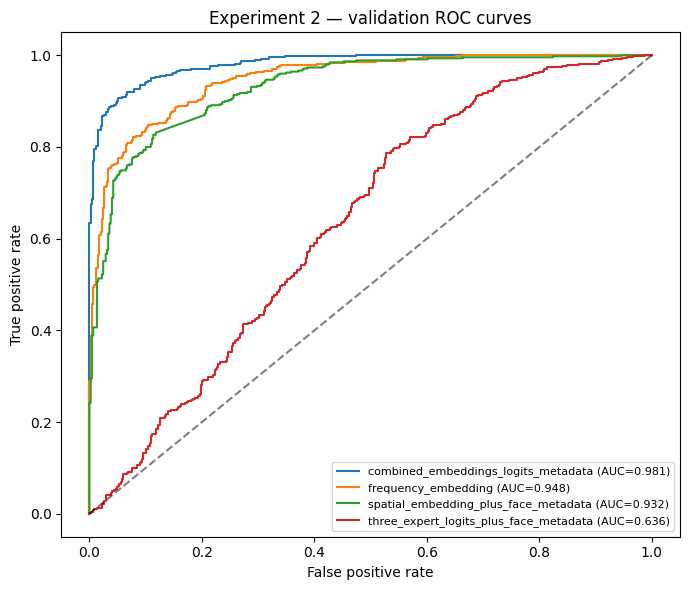

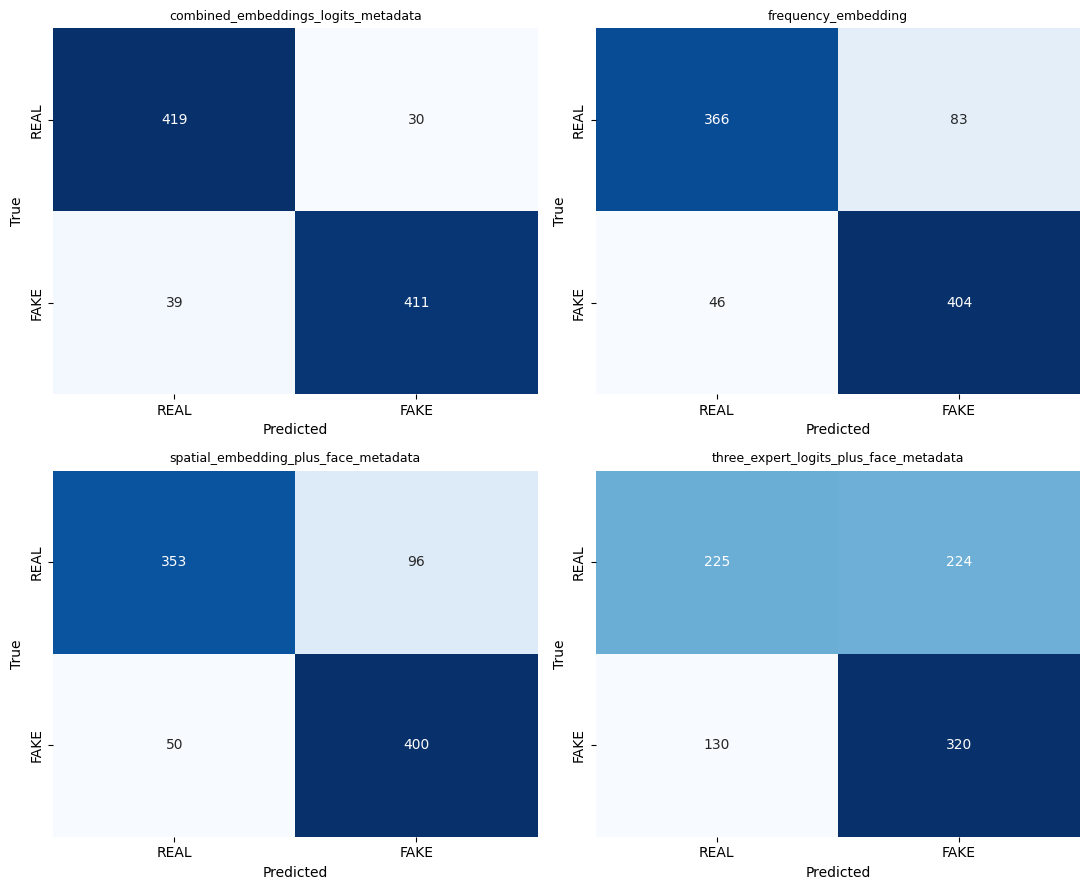

In [16]:
# CELL 13 — ROC AND CONFUSION-MATRIX PLOTS
fig,ax=plt.subplots(figsize=(7,6))
for probe_name,g in probe_predictions_df.groupby("probe"):
    fpr,tpr,_=roc_curve(g["true_label"].astype(int),g["fake_probability"].astype(float))
    auc=roc_auc_score(g["true_label"].astype(int),g["fake_probability"].astype(float))
    ax.plot(fpr,tpr,label=f"{probe_name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=.5);ax.set_xlabel("False positive rate");ax.set_ylabel("True positive rate")
ax.set_title("Experiment 2 — validation ROC curves");ax.legend(fontsize=8);plt.tight_layout()
plt.savefig(OUTPUT_DIR/"Experiment2_Validation_ROC_Curves.png",dpi=180,bbox_inches="tight");plt.show()

ordered=probe_metrics["model"].tolist();fig,axes=plt.subplots(2,2,figsize=(11,9))
for ax,name in zip(axes.flat,ordered):
    g=probe_predictions_df[probe_predictions_df["probe"].eq(name)]
    cm=confusion_matrix(g["true_label"].astype(int),g["prediction"].astype(int),labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,xticklabels=["REAL","FAKE"],yticklabels=["REAL","FAKE"])
    ax.set_title(name,fontsize=9);ax.set_xlabel("Predicted");ax.set_ylabel("True")
plt.tight_layout();plt.savefig(OUTPUT_DIR/"Experiment2_Probe_Confusion_Matrices.png",dpi=180,bbox_inches="tight");plt.show()

In [17]:
# CELL 14 — DECISION SUMMARY AND EXPORT BUNDLE
best=probe_metrics.iloc[0].to_dict()
summary={
    "experiment":"DefakeX Experiment 2 — frozen expert diagnostics and linear probes",
    "seed":SEED,"train_images":4194,"validation_images":899,"locked_test_images_used":0,
    "stable_diffusion_added":False,
    "stable_diffusion_reason":"Excluded from the first native-domain diagnostic to avoid easy-generator shortcuts and inflated validation performance.",
    "feature_preprocessing":{
        "frequency":"full RGB -> bicubic 256 -> center crop 224 -> per-channel FFT log1p magnitude -> clip/divide 14",
        "spatial":"largest MTCNN face -> 25% square margin -> resize 256 -> center crop 224 -> ImageNet normalization",
    },
    "model_selection":"C selected by 3-fold StratifiedGroupKFold on training; threshold selected on training OOF predictions; validation used only for evaluation.",
    "best_probe_by_validation_auc":best,
    "next_decision_rules":{
        "frequency_embedding_auc_ge_0.75":"Fine-tune frequency head, then final blocks.",
        "spatial_embedding_auc_ge_0.75":"Fine-tune spatial head, then final blocks.",
        "combined_materially_better":"Retain both branches for fusion development.",
        "branch_near_random":"Do not carry that branch unchanged into new fusion.",
    },
}
with open(OUTPUT_DIR/"Experiment2_Summary.json","w") as f:json.dump(summary,f,indent=2,default=float)
(OUTPUT_DIR/"README.txt").write_text(
    "Experiment 2 uses only DefakeX train and validation. The locked test was not loaded. "
    "Regularization and thresholds were selected from grouped training OOF predictions. "
    "Validation results decide which frozen representations are worth fine-tuning.\n")

archive=shutil.make_archive("/kaggle/working/DefakeX_Experiment2_Frozen_Expert_Diagnostics","zip",OUTPUT_DIR)
print(json.dumps(summary,indent=2,default=float))
print("ZIP:",archive);display(FileLink(archive))

{
  "experiment": "DefakeX Experiment 2 \u2014 frozen expert diagnostics and linear probes",
  "seed": 42,
  "train_images": 4194,
  "validation_images": 899,
  "locked_test_images_used": 0,
  "stable_diffusion_added": false,
  "stable_diffusion_reason": "Excluded from the first native-domain diagnostic to avoid easy-generator shortcuts and inflated validation performance.",
  "feature_preprocessing": {
    "frequency": "full RGB -> bicubic 256 -> center crop 224 -> per-channel FFT log1p magnitude -> clip/divide 14",
    "spatial": "largest MTCNN face -> 25% square margin -> resize 256 -> center crop 224 -> ImageNet normalization"
  },
  "model_selection": "C selected by 3-fold StratifiedGroupKFold on training; threshold selected on training OOF predictions; validation used only for evaluation.",
  "best_probe_by_validation_auc": {
    "model": "combined_embeddings_logits_metadata",
    "threshold": 0.5349999999999999,
    "n": 899,
    "accuracy": 0.9232480533926585,
    "balanced_acc

/kaggle/working/DefakeX_Experiment2_Frozen_Expert_Diagnostics.zip